In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


In [2]:
# ── Core ──────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ─────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn: preprocessing & models ──────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

# ── Class imbalance fix ────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── XGBoost ───────────────────────────────────────────
from xgboost import XGBClassifier

# ── SHAP (explainability) ─────────────────────────────
import shap

# ── Misc ──────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Data types and null check
print("=== Data Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum().sum(), "missing values found")

print("\n=== Basic Statistics ===")
df.describe()

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


=== Transaction Counts ===
Legitimate : 284,315  (99.83%)
Fraudulent : 492  (0.17%)

Imbalance ratio: 577:1


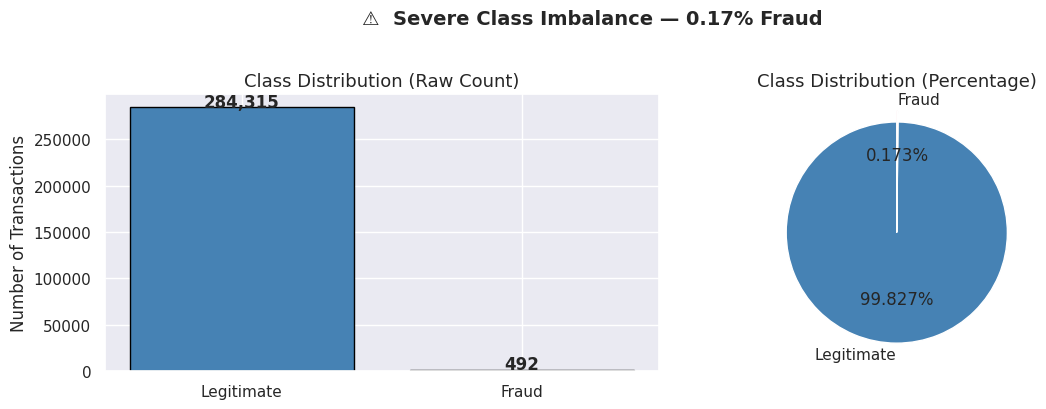


💡 If we predict ALL transactions as legitimate:
   Accuracy = 99.83% — looks great but catches ZERO fraud!
   This is why accuracy alone is a useless metric here.


In [5]:
# Count of each class
fraud_count = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

print("=== Transaction Counts ===")
print(f"Legitimate : {fraud_count[0]:,}  ({fraud_pct[0]:.2f}%)")
print(f"Fraudulent : {fraud_count[1]:,}  ({fraud_pct[1]:.2f}%)")
print(f"\nImbalance ratio: {fraud_count[0] // fraud_count[1]}:1")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Legitimate', 'Fraud'], fraud_count.values, 
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Class Distribution (Raw Count)', fontsize=13)
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(fraud_count.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_count.values, labels=['Legitimate', 'Fraud'],
            colors=['steelblue', 'crimson'], autopct='%1.3f%%',
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Distribution (Percentage)', fontsize=13)

plt.suptitle('⚠️  Severe Class Imbalance — 0.17% Fraud', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 If we predict ALL transactions as legitimate:")
print(f"   Accuracy = {fraud_pct[0]:.2f}% — looks great but catches ZERO fraud!")
print("   This is why accuracy alone is a useless metric here.")

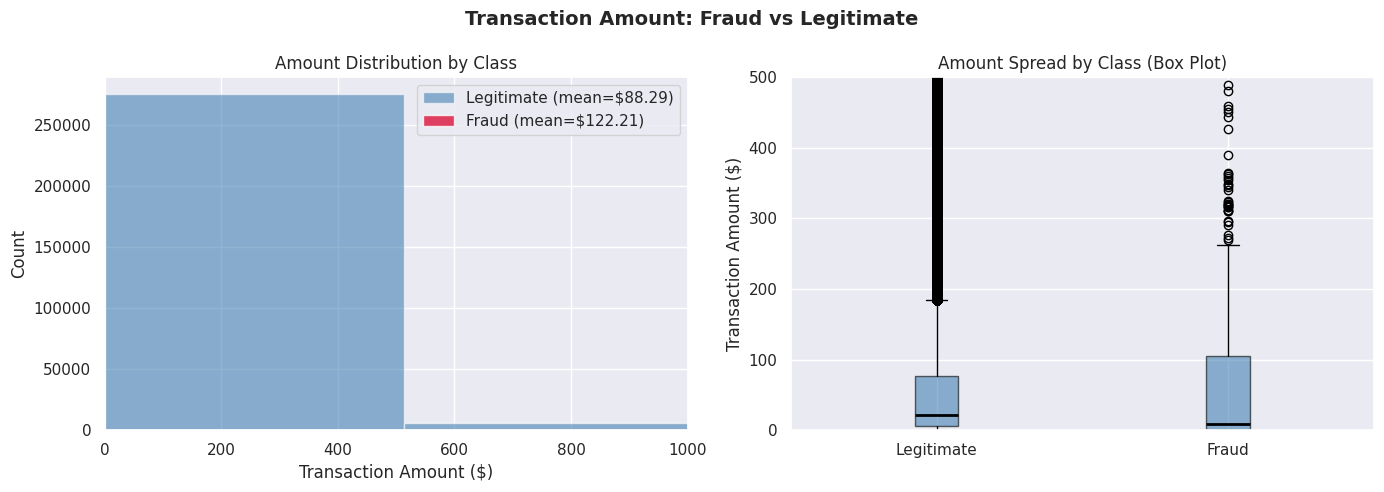

=== Amount Statistics ===
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount distribution for each class
fraud_amounts    = df[df['Class'] == 1]['Amount']
legit_amounts    = df[df['Class'] == 0]['Amount']

# Histogram
axes[0].hist(legit_amounts, bins=50, alpha=0.6, color='steelblue', 
             label=f'Legitimate (mean=${legit_amounts.mean():.2f})')
axes[0].hist(fraud_amounts, bins=50, alpha=0.8, color='crimson',  
             label=f'Fraud (mean=${fraud_amounts.mean():.2f})')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Amount Distribution by Class')
axes[0].set_xlim(0, 1000)   # zoom in — outliers skew the x-axis badly
axes[0].legend()

# Box plot
axes[1].boxplot([legit_amounts, fraud_amounts],
                labels=['Legitimate', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_ylabel('Transaction Amount ($)')
axes[1].set_title('Amount Spread by Class (Box Plot)')
axes[1].set_ylim(0, 500)    # zoom in for readability

plt.suptitle('Transaction Amount: Fraud vs Legitimate', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== Amount Statistics ===")
print(df.groupby('Class')['Amount'].describe().round(2))

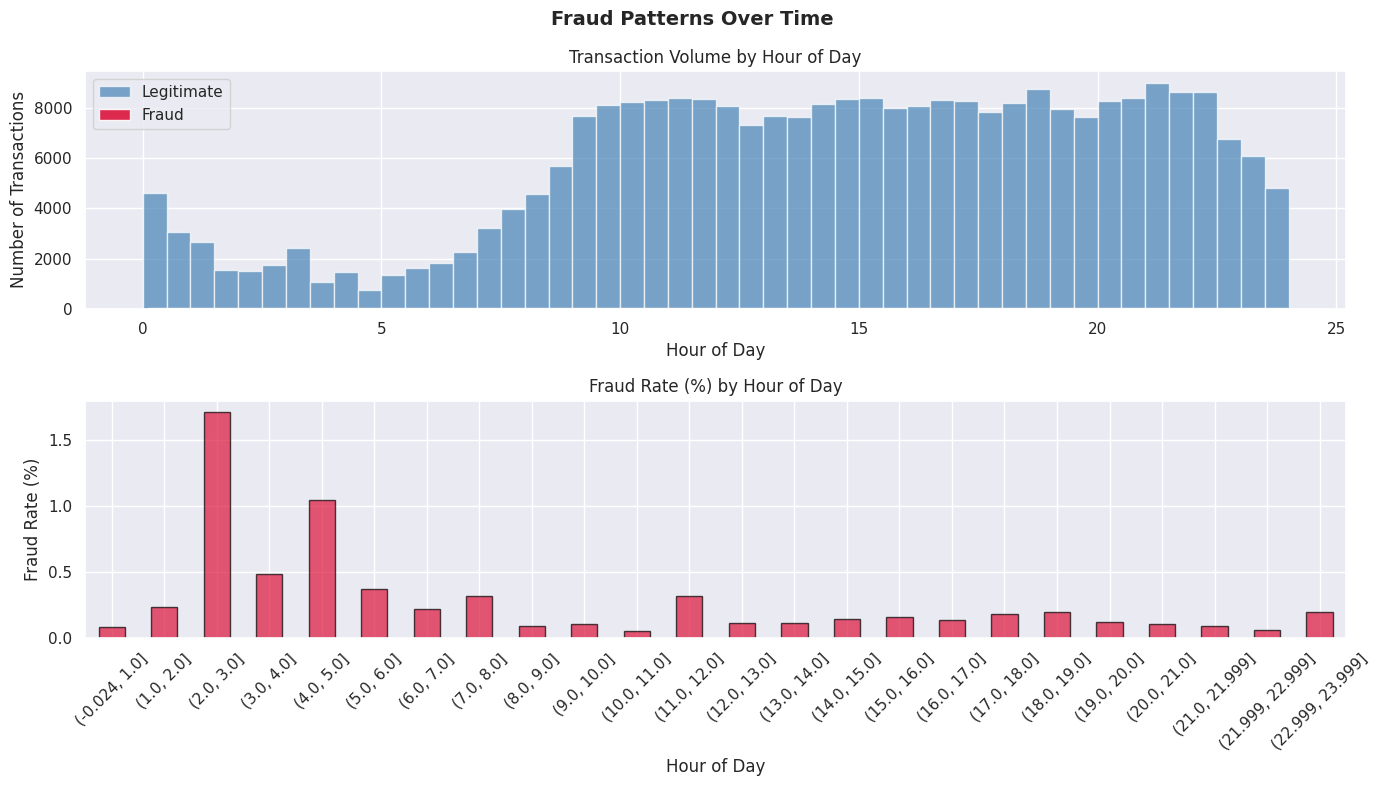

=== Hour with highest fraud RATE ===
Hour (2.0, 3.0]: 1.713% fraud rate


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Convert time from seconds to hours — use a temp variable, DON'T add to df
hour_all   = (df['Time'] / 3600) % 24
hour_legit = hour_all[df['Class'] == 0]
hour_fraud = hour_all[df['Class'] == 1]

# Plot 1: Transaction volume over time
axes[0].hist(hour_legit, bins=48, color='steelblue', alpha=0.7, label='Legitimate')
axes[0].hist(hour_fraud, bins=48, color='crimson',   alpha=0.9, label='Fraud')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_title('Transaction Volume by Hour of Day')
axes[0].legend()

# Plot 2: Fraud rate by hour
hour_bin  = pd.cut(hour_all, bins=24)
temp_df   = pd.DataFrame({'Hour_bin': hour_bin, 'Class': df['Class']})
fraud_rate = temp_df.groupby('Hour_bin')['Class'].mean() * 100

fraud_rate.plot(kind='bar', ax=axes[1], color='crimson', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate (%) by Hour of Day')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Fraud Patterns Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== Hour with highest fraud RATE ===")
peak = fraud_rate.idxmax()
print(f"Hour {peak}: {fraud_rate.max():.3f}% fraud rate")

# ✅ df is NOT modified — no Hour or Hour_bin columns added

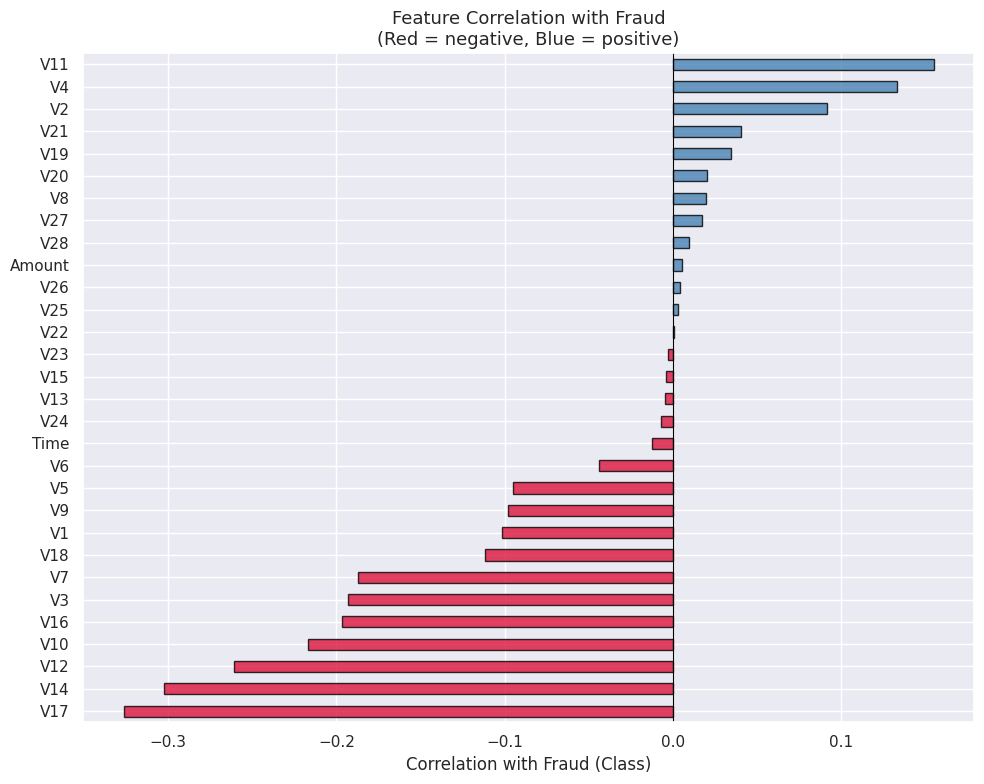

=== Top 5 features POSITIVELY correlated with fraud ===
V19    0.0348
V21    0.0404
V2     0.0913
V4     0.1334
V11    0.1549
Name: Class, dtype: float64

=== Top 5 features NEGATIVELY correlated with fraud ===
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965
Name: Class, dtype: float64


In [8]:
# Correlation of each feature with Class label
correlations = df.corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(10, 8))
colors = ['crimson' if x < 0 else 'steelblue' for x in correlations]
correlations.plot(kind='barh', color=colors, edgecolor='black', alpha=0.8)
plt.xlabel('Correlation with Fraud (Class)')
plt.title('Feature Correlation with Fraud\n(Red = negative, Blue = positive)', fontsize=13)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("=== Top 5 features POSITIVELY correlated with fraud ===")
print(correlations.tail(5).round(4))
print("\n=== Top 5 features NEGATIVELY correlated with fraud ===")
print(correlations.head(5).round(4))

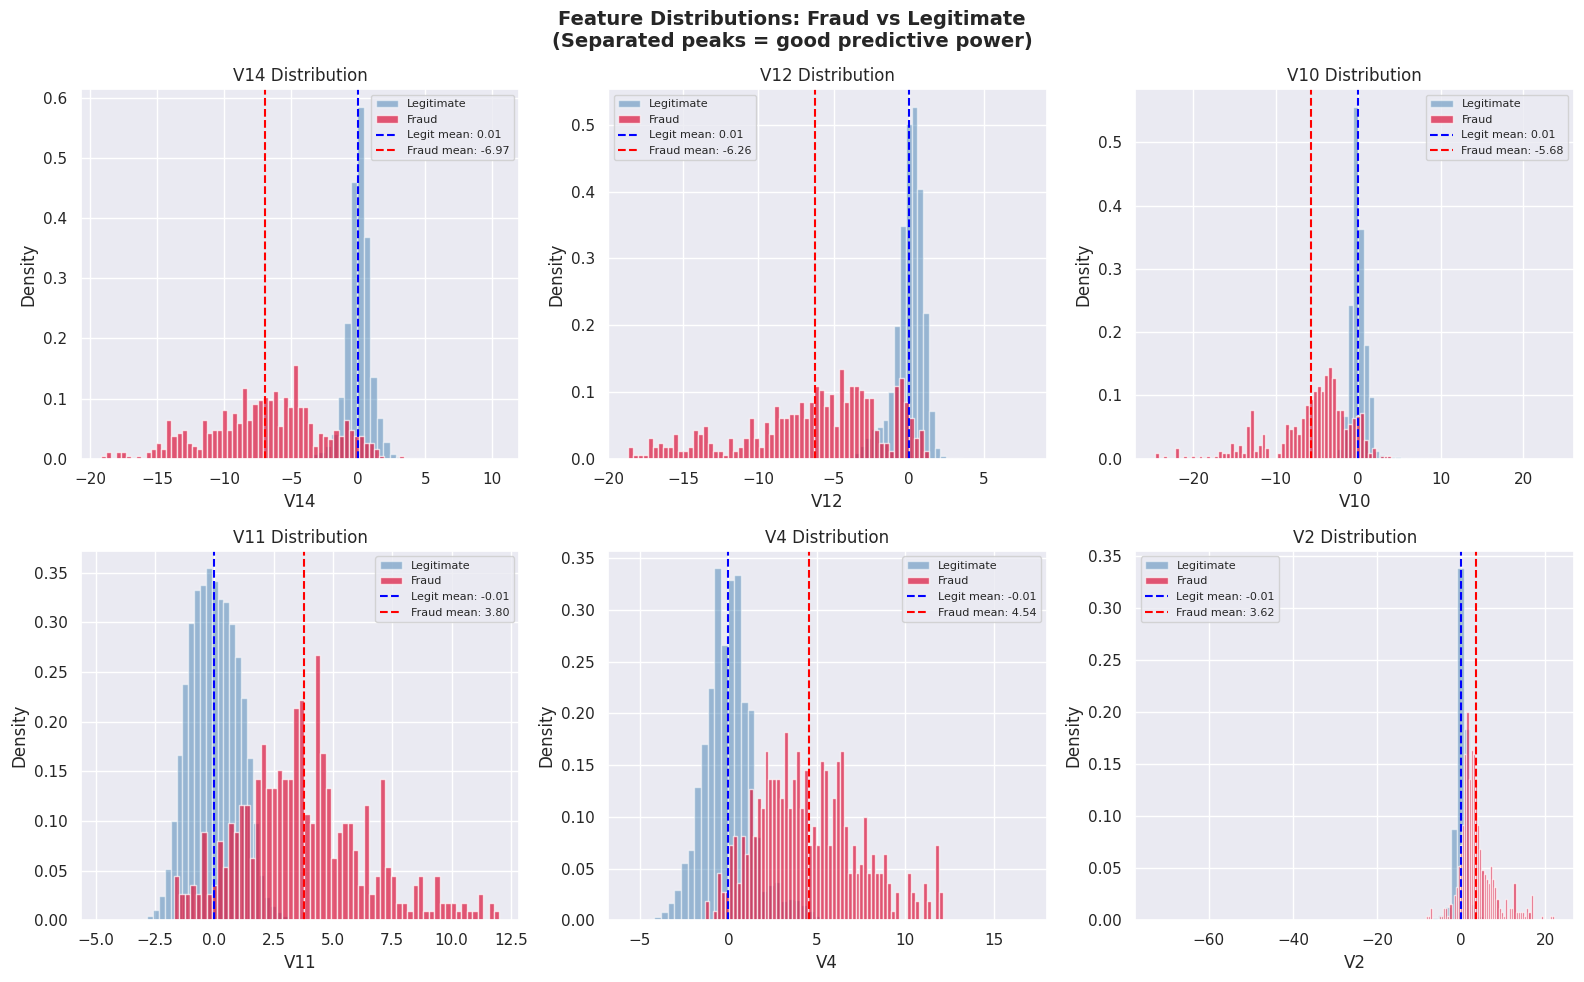

In [9]:
# Top features from correlation analysis
top_features = ['V14', 'V12', 'V10', 'V11', 'V4', 'V2']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    fraud_vals = df[df['Class'] == 1][feature]
    legit_vals = df[df['Class'] == 0][feature]
    
    axes[i].hist(legit_vals, bins=60, alpha=0.5, color='steelblue',
                 label='Legitimate', density=True)
    axes[i].hist(fraud_vals, bins=60, alpha=0.7, color='crimson',
                 label='Fraud', density=True)
    
    axes[i].set_title(f'{feature} Distribution', fontsize=12)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')
    axes[i].legend()
    
    # Mark the means
    axes[i].axvline(legit_vals.mean(), color='blue',  
                    linestyle='--', linewidth=1.5, label=f'Legit mean: {legit_vals.mean():.2f}')
    axes[i].axvline(fraud_vals.mean(), color='red',   
                    linestyle='--', linewidth=1.5, label=f'Fraud mean: {fraud_vals.mean():.2f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Fraud vs Legitimate\n(Separated peaks = good predictive power)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']

print("Feature matrix shape:", X.shape)

# Two separate scalers — one per column
amount_scaler = StandardScaler()
time_scaler   = StandardScaler()

X['Amount'] = amount_scaler.fit_transform(X[['Amount']])
X['Time']   = time_scaler.fit_transform(X[['Time']])

print("\n✅ Amount and Time scaled")
print("Amount mean:", round(X['Amount'].mean(), 4))
print("Time   mean:", round(X['Time'].mean(), 4))

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Data split complete")
print(f"Training set : {X_train.shape[0]:,} transactions")
print(f"Test set     : {X_test.shape[0]:,} transactions")
print(f"Fraud in train : {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Fraud in test  : {y_test.sum()} ({y_test.mean()*100:.2f}%)")

Feature matrix shape: (284807, 30)

✅ Amount and Time scaled
Amount mean: -0.0
Time   mean: -0.0

✅ Data split complete
Training set : 227,845 transactions
Test set     : 56,962 transactions
Fraud in train : 394 (0.17%)
Fraud in test  : 98 (0.17%)


In [11]:
# Train logistic regression with NO imbalance handling first
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train, y_train)

# Predictions
y_pred_baseline = lr_baseline.predict(X_test)
y_prob_baseline = lr_baseline.predict_proba(X_test)[:, 1]

# Results
print("=" * 55)
print("   BASELINE LOGISTIC REGRESSION (no imbalance fix)")
print("=" * 55)
print(f"\nAccuracy : {(y_pred_baseline == y_test).mean()*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_baseline):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_baseline, 
                            target_names=['Legitimate', 'Fraud']))

print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred_baseline)
print(cm)
print(f"\nTrue  Positives (fraud caught)   : {cm[1][1]}")
print(f"False Negatives (fraud missed)   : {cm[1][0]}  ← DANGEROUS")
print(f"False Positives (legit blocked)  : {cm[0][1]}")
print(f"True  Negatives (legit passed)   : {cm[0][0]}")

   BASELINE LOGISTIC REGRESSION (no imbalance fix)

Accuracy : 99.92%
ROC-AUC  : 0.9573

--- Classification Report ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

--- Confusion Matrix ---
[[56851    13]
 [   35    63]]

True  Positives (fraud caught)   : 63
False Negatives (fraud missed)   : 35  ← DANGEROUS
False Positives (legit blocked)  : 13
True  Negatives (legit passed)   : 56851


In [12]:
# class_weight='balanced' tells the model:
# "treat each fraud as if it were 577x more important than a legit transaction"
lr_balanced = LogisticRegression(max_iter=1000, random_state=42,
                                  class_weight='balanced')
lr_balanced.fit(X_train, y_train)

y_pred_balanced = lr_balanced.predict(X_test)
y_prob_balanced = lr_balanced.predict_proba(X_test)[:, 1]

print("=" * 55)
print("   LOGISTIC REGRESSION (class_weight='balanced')")
print("=" * 55)
print(f"\nAccuracy : {(y_pred_balanced == y_test).mean()*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_balanced):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_balanced,
                            target_names=['Legitimate', 'Fraud']))

cm2 = confusion_matrix(y_test, y_pred_balanced)
print("--- Confusion Matrix ---")
print(cm2)
print(f"\nTrue  Positives (fraud caught)   : {cm2[1][1]}")
print(f"False Negatives (fraud missed)   : {cm2[1][0]}  ← DANGEROUS")
print(f"False Positives (legit blocked)  : {cm2[0][1]}")

print("\n--- Improvement over baseline ---")
print(f"Fraud caught : {cm2[1][1]} vs {cm[1][1]} before  (+{cm2[1][1]-cm[1][1]})")
print(f"Fraud missed : {cm2[1][0]} vs {cm[1][0]} before  ({cm2[1][0]-cm[1][0]:+d})")

   LOGISTIC REGRESSION (class_weight='balanced')

Accuracy : 97.55%
ROC-AUC  : 0.9722

--- Classification Report ---
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

--- Confusion Matrix ---
[[55475  1389]
 [    8    90]]

True  Positives (fraud caught)   : 90
False Negatives (fraud missed)   : 8  ← DANGEROUS
False Positives (legit blocked)  : 1389

--- Improvement over baseline ---
Fraud caught : 90 vs 63 before  (+27)
Fraud missed : 8 vs 35 before  (-27)


In [13]:
print("Applying SMOTE — this creates synthetic fraud transactions...")
print(f"Before SMOTE: {y_train.value_counts()[0]:,} legit | {y_train.value_counts()[1]:,} fraud")

# SMOTE creates synthetic fraud samples until classes are balanced
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After  SMOTE: {y_train_smote.value_counts()[0]:,} legit | {y_train_smote.value_counts()[1]:,} fraud")
print(f"\n✅ Training set is now perfectly balanced!")

# Train Logistic Regression on SMOTE data
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = lr_smote.predict(X_test)
y_prob_smote = lr_smote.predict_proba(X_test)[:, 1]

print("\n" + "=" * 55)
print("   LOGISTIC REGRESSION + SMOTE")
print("=" * 55)
print(f"\nAccuracy : {(y_pred_smote == y_test).mean()*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_smote):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_smote,
                            target_names=['Legitimate', 'Fraud']))

cm3 = confusion_matrix(y_test, y_pred_smote)
print("--- Confusion Matrix ---")
print(cm3)
print(f"\nTrue  Positives (fraud caught)   : {cm3[1][1]}")
print(f"False Negatives (fraud missed)   : {cm3[1][0]}  ← DANGEROUS")
print(f"False Positives (legit blocked)  : {cm3[0][1]}")

Applying SMOTE — this creates synthetic fraud transactions...
Before SMOTE: 227,451 legit | 394 fraud
After  SMOTE: 227,451 legit | 227,451 fraud

✅ Training set is now perfectly balanced!

   LOGISTIC REGRESSION + SMOTE

Accuracy : 97.43%
ROC-AUC  : 0.9698

--- Classification Report ---
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

--- Confusion Matrix ---
[[55406  1458]
 [    8    90]]

True  Positives (fraud caught)   : 90
False Negatives (fraud missed)   : 8  ← DANGEROUS
False Positives (legit blocked)  : 1458


In [14]:
print("Training Random Forest... (may take 1-2 minutes on Kaggle)")

rf = RandomForestClassifier(
    n_estimators=100,       # 100 decision trees
    class_weight='balanced',
    random_state=42,
    n_jobs=-1               # use all CPU cores
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print("\n" + "=" * 55)
print("   RANDOM FOREST (class_weight='balanced')")
print("=" * 55)
print(f"\nAccuracy : {(y_pred_rf == y_test).mean()*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_rf,
                            target_names=['Legitimate', 'Fraud']))

cm4 = confusion_matrix(y_test, y_pred_rf)
print("--- Confusion Matrix ---")
print(cm4)
print(f"\nTrue  Positives (fraud caught)   : {cm4[1][1]}")
print(f"False Negatives (fraud missed)   : {cm4[1][0]}  ← DANGEROUS")
print(f"False Positives (legit blocked)  : {cm4[0][1]}")

print("\n--- vs Best Logistic Regression ---")
print(f"Fraud caught : {cm4[1][1]} vs 90 before")
print(f"False alarms : {cm4[0][1]} vs 1389 before")

Training Random Forest... (may take 1-2 minutes on Kaggle)

   RANDOM FOREST (class_weight='balanced')

Accuracy : 99.95%
ROC-AUC  : 0.9529

--- Classification Report ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

--- Confusion Matrix ---
[[56861     3]
 [   25    73]]

True  Positives (fraud caught)   : 73
False Negatives (fraud missed)   : 25  ← DANGEROUS
False Positives (legit blocked)  : 3

--- vs Best Logistic Regression ---
Fraud caught : 73 vs 90 before
False alarms : 3 vs 1389 before


In [15]:
# scale_pos_weight = ratio of negative to positive class
# = 227451 / 394 = ~577 (our exact imbalance ratio)
scale = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"scale_pos_weight = {scale:.1f}")

print("\nTraining XGBoost... (may take 1-2 minutes)")

xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,   # handles imbalance
    random_state=42,
    eval_metric='aucpr',      # optimize for precision-recall AUC
    n_jobs=-1
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb  = xgb.predict_proba(X_test)[:, 1]

print("\n" + "=" * 55)
print("   XGBOOST (scale_pos_weight)")
print("=" * 55)
print(f"\nAccuracy : {(y_pred_xgb == y_test).mean()*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_xgb,
                            target_names=['Legitimate', 'Fraud']))

cm5 = confusion_matrix(y_test, y_pred_xgb)
print("--- Confusion Matrix ---")
print(cm5)
print(f"\nTrue  Positives (fraud caught)   : {cm5[1][1]}")
print(f"False Negatives (fraud missed)   : {cm5[1][0]}  ← DANGEROUS")
print(f"False Positives (legit blocked)  : {cm5[0][1]}")

scale_pos_weight = 577.3

Training XGBoost... (may take 1-2 minutes)

   XGBOOST (scale_pos_weight)

Accuracy : 99.95%
ROC-AUC  : 0.9682

--- Classification Report ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

--- Confusion Matrix ---
[[56853    11]
 [   16    82]]

True  Positives (fraud caught)   : 82
False Negatives (fraud missed)   : 16  ← DANGEROUS
False Positives (legit blocked)  : 11


In [16]:
print("Training Tuned XGBoost... (2-3 minutes)")

xgb_tuned = XGBClassifier(
    n_estimators=300,         # more trees = better learning
    max_depth=6,              # deeper trees catch complex patterns
    learning_rate=0.05,       # slower learning = more careful
    subsample=0.8,            # use 80% of data per tree (prevents overfitting)
    colsample_bytree=0.8,     # use 80% of features per tree
    min_child_weight=1,
    gamma=0.1,                # minimum gain to make a split
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)
xgb_tuned.fit(X_train, y_train)

y_pred_xgb_t = xgb_tuned.predict(X_test)
y_prob_xgb_t  = xgb_tuned.predict_proba(X_test)[:, 1]

print("\n" + "=" * 55)
print("   TUNED XGBOOST")
print("=" * 55)
print(f"\nAccuracy : {(y_pred_xgb_t == y_test).mean()*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_xgb_t):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_xgb_t,
                            target_names=['Legitimate', 'Fraud']))

cm6 = confusion_matrix(y_test, y_pred_xgb_t)
print("--- Confusion Matrix ---")
print(cm6)
print(f"\nTrue  Positives (fraud caught)   : {cm6[1][1]}")
print(f"False Negatives (fraud missed)   : {cm6[1][0]}  ← DANGEROUS")
print(f"False Positives (legit blocked)  : {cm6[0][1]}")

print("\n--- vs Base XGBoost ---")
print(f"Fraud caught : {cm6[1][1]} vs 82 before")
print(f"False alarms : {cm6[0][1]} vs 11 before")

Training Tuned XGBoost... (2-3 minutes)

   TUNED XGBOOST

Accuracy : 99.95%
ROC-AUC  : 0.9800

--- Classification Report ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.85      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

--- Confusion Matrix ---
[[56850    14]
 [   16    82]]

True  Positives (fraud caught)   : 82
False Negatives (fraud missed)   : 16  ← DANGEROUS
False Positives (legit blocked)  : 14

--- vs Base XGBoost ---
Fraud caught : 82 vs 82 before
False alarms : 14 vs 11 before


In [17]:
results = {
    'Model': [
        'LR Baseline',
        'LR + Class Weights',
        'LR + SMOTE',
        'Random Forest',
        'XGBoost',
        'XGBoost Tuned'
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_baseline),
        roc_auc_score(y_test, y_prob_balanced),
        roc_auc_score(y_test, y_prob_smote),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_xgb_t)
    ],
    'Fraud Caught (Recall)': [
        cm[1][1],  cm2[1][1], cm3[1][1],
        cm4[1][1], cm5[1][1], cm6[1][1]
    ],
    'False Alarms': [
        cm[0][1],  cm2[0][1], cm3[0][1],
        cm4[0][1], cm5[0][1], cm6[0][1]
    ],
    'Fraud Missed': [
        cm[1][0],  cm2[1][0], cm3[1][0],
        cm4[1][0], cm5[1][0], cm6[1][0]
    ]
}

df_results = pd.DataFrame(results)
df_results['ROC-AUC'] = df_results['ROC-AUC'].round(4)
df_results['Recall %'] = (df_results['Fraud Caught (Recall)'] / 98 * 100).round(1)

print(df_results.to_string(index=False))

print("\n✅ Best overall model: Tuned XGBoost")
print("   ROC-AUC 0.98 | Catches 82/98 fraud | Only 14 false alarms")

             Model  ROC-AUC  Fraud Caught (Recall)  False Alarms  Fraud Missed  Recall %
       LR Baseline   0.9573                     63            13            35      64.3
LR + Class Weights   0.9722                     90          1389             8      91.8
        LR + SMOTE   0.9698                     90          1458             8      91.8
     Random Forest   0.9529                     73             3            25      74.5
           XGBoost   0.9682                     82            11            16      83.7
     XGBoost Tuned   0.9800                     82            14            16      83.7

✅ Best overall model: Tuned XGBoost
   ROC-AUC 0.98 | Catches 82/98 fraud | Only 14 false alarms


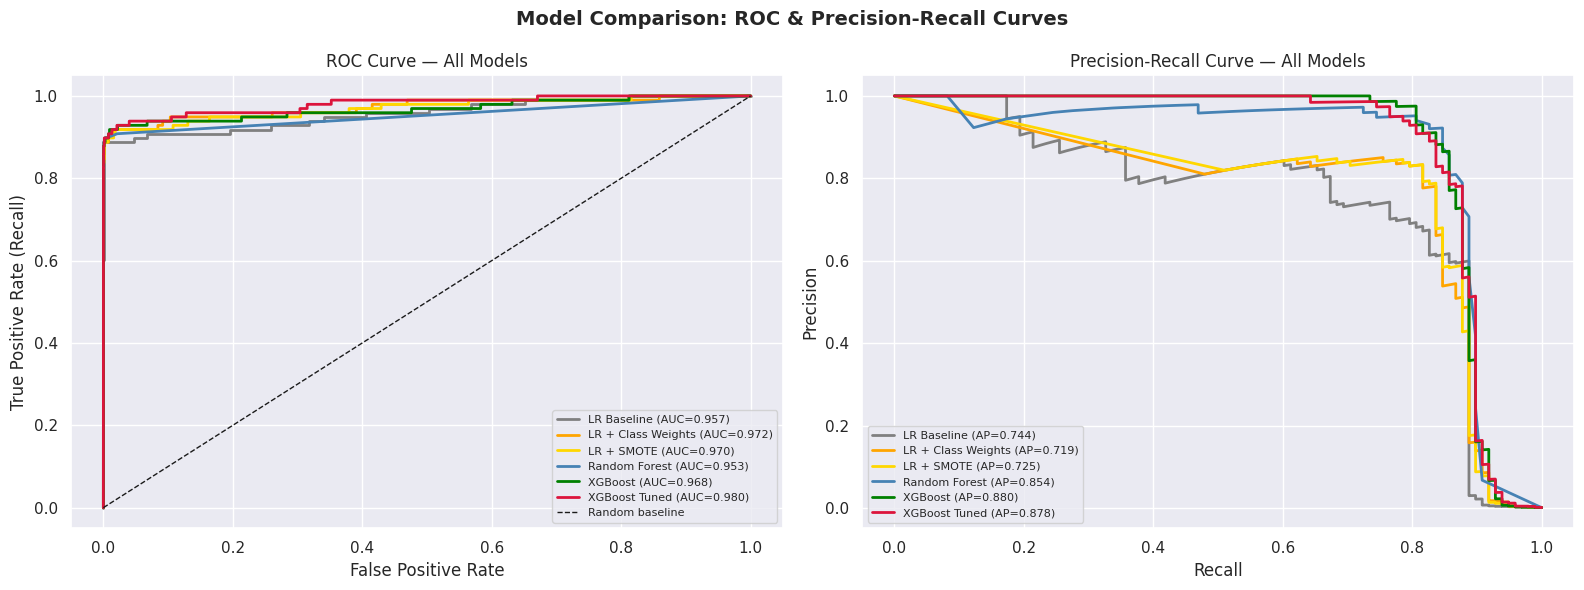

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: ROC Curves ────────────────────────────────
models = {
    'LR Baseline'       : y_prob_baseline,
    'LR + Class Weights': y_prob_balanced,
    'LR + SMOTE'        : y_prob_smote,
    'Random Forest'     : y_prob_rf,
    'XGBoost'           : y_prob_xgb,
    'XGBoost Tuned'     : y_prob_xgb_t,
}
colors = ['gray', 'orange', 'gold', 'steelblue', 'green', 'crimson']

for (name, probs), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

axes[0].plot([0,1], [0,1], 'k--', linewidth=1, label='Random baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve — All Models')
axes[0].legend(fontsize=8)

# ── Plot 2: Precision-Recall Curves ──────────────────
for (name, probs), color in zip(models.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(recall, precision, label=f'{name} (AP={ap:.3f})', 
                 color=color, linewidth=2)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — All Models')
axes[1].legend(fontsize=8)

plt.suptitle('Model Comparison: ROC & Precision-Recall Curves', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

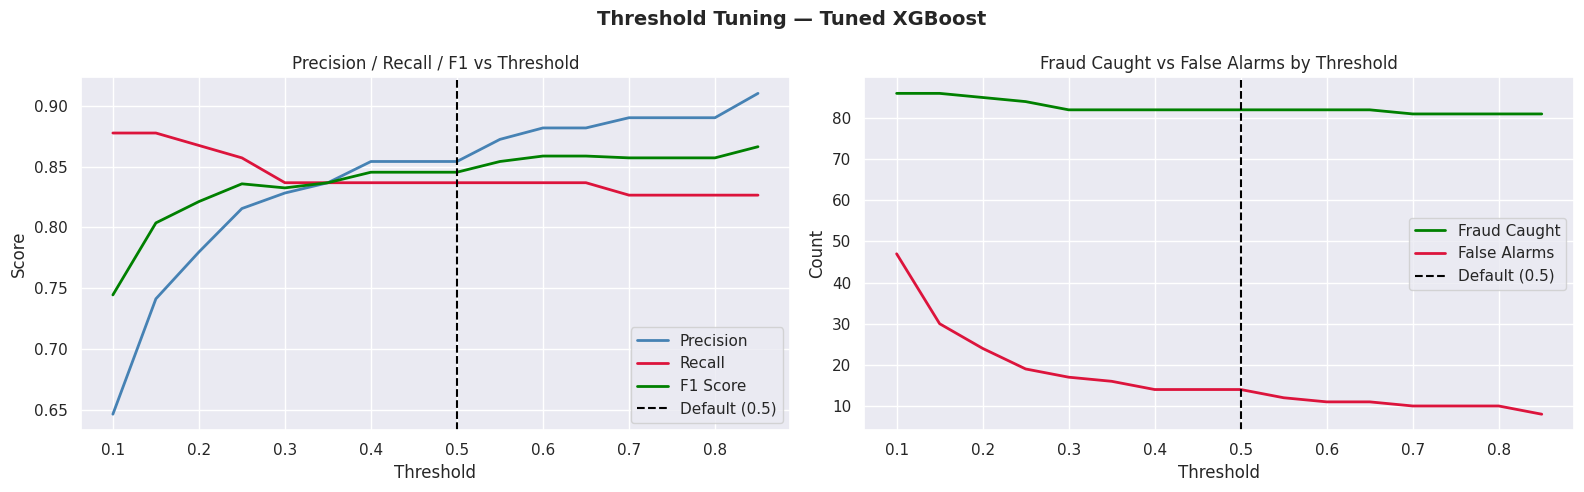

=== Best threshold by F1: 0.85 ===
Fraud caught : 81
False alarms : 8
Precision    : 0.910
Recall       : 0.827
F1           : 0.866


In [19]:
# By default, models predict fraud if probability > 0.5
# We can lower this threshold to catch MORE fraud (higher recall)
# at the cost of more false alarms (lower precision)

thresholds = np.arange(0.1, 0.9, 0.05)

precisions, recalls, f1s, false_alarms, caught = [], [], [], [], []

for thresh in thresholds:
    y_pred_thresh = (y_prob_xgb_t >= thresh).astype(int)
    
    tp = ((y_pred_thresh == 1) & (y_test == 1)).sum()
    fp = ((y_pred_thresh == 1) & (y_test == 0)).sum()
    fn = ((y_pred_thresh == 0) & (y_test == 1)).sum()
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)
    false_alarms.append(fp)
    caught.append(tp)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(thresholds, precisions, 'steelblue', linewidth=2, label='Precision')
axes[0].plot(thresholds, recalls,    'crimson',   linewidth=2, label='Recall')
axes[0].plot(thresholds, f1s,        'green',     linewidth=2, label='F1 Score')
axes[0].axvline(x=0.5, color='black', linestyle='--', label='Default (0.5)')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs Threshold')
axes[0].legend()

axes[1].plot(thresholds, caught,      'green',   linewidth=2, label='Fraud Caught')
axes[1].plot(thresholds, false_alarms,'crimson', linewidth=2, label='False Alarms')
axes[1].axvline(x=0.5, color='black', linestyle='--', label='Default (0.5)')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Count')
axes[1].set_title('Fraud Caught vs False Alarms by Threshold')
axes[1].legend()

plt.suptitle('Threshold Tuning — Tuned XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Best F1 threshold
best_idx   = np.argmax(f1s)
best_thresh = thresholds[best_idx]
print(f"=== Best threshold by F1: {best_thresh:.2f} ===")
print(f"Fraud caught : {caught[best_idx]}")
print(f"False alarms : {false_alarms[best_idx]}")
print(f"Precision    : {precisions[best_idx]:.3f}")
print(f"Recall       : {recalls[best_idx]:.3f}")
print(f"F1           : {f1s[best_idx]:.3f}")

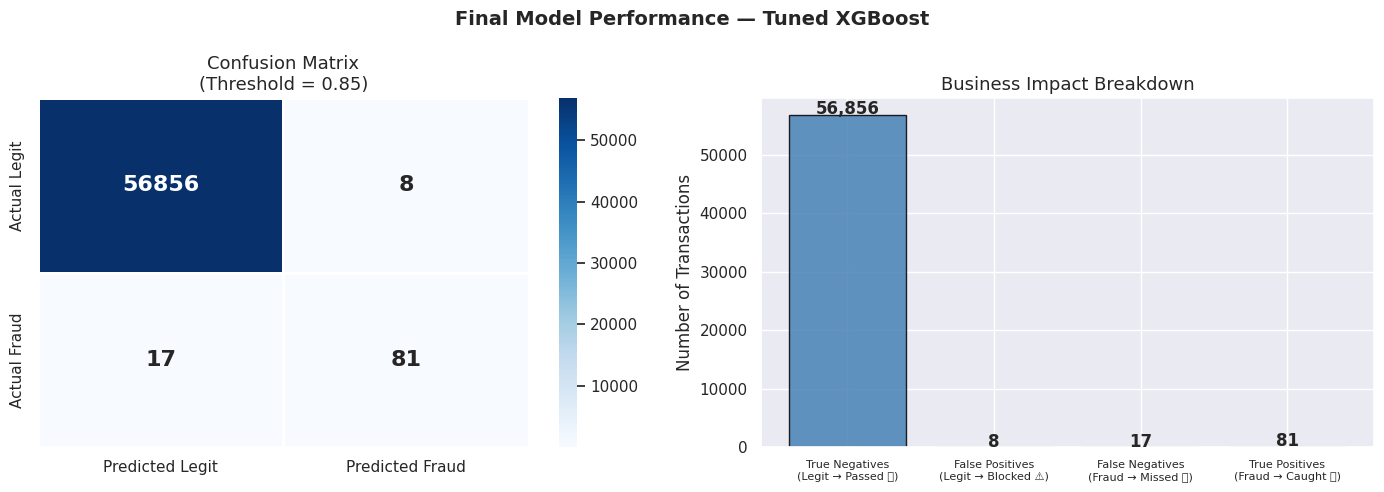


=== Final Model Summary ===
Threshold    : 0.85
ROC-AUC      : 0.9800
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.91      0.83      0.87        98

    accuracy                           1.00     56962
   macro avg       0.95      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [20]:
# Apply best threshold
y_pred_final = (y_prob_xgb_t >= best_thresh).astype(int)

cm_final = confusion_matrix(y_test, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Confusion Matrix Heatmap ─────────────────
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'],
            ax=axes[0], linewidths=2, linecolor='white',
            annot_kws={"size": 16, "weight": "bold"})
axes[0].set_title(f'Confusion Matrix\n(Threshold = {best_thresh:.2f})', fontsize=13)

# ── Plot 2: Business cost breakdown ──────────────────
tn, fp, fn, tp = cm_final.ravel()

categories = ['True Negatives\n(Legit → Passed ✅)',
              'False Positives\n(Legit → Blocked ⚠️)',
              'False Negatives\n(Fraud → Missed ❌)',
              'True Positives\n(Fraud → Caught ✅)']
values = [tn, fp, fn, tp]
colors = ['steelblue', 'orange', 'crimson', 'green']

bars = axes[1].bar(categories, values, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Business Impact Breakdown', fontsize=13)
axes[1].set_ylabel('Number of Transactions')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 100,
                 f'{val:,}', ha='center', fontweight='bold')
axes[1].tick_params(axis='x', labelsize=8)

plt.suptitle('Final Model Performance — Tuned XGBoost', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n=== Final Model Summary ===")
print(f"Threshold    : {best_thresh:.2f}")
print(f"ROC-AUC      : {roc_auc_score(y_test, y_prob_xgb_t):.4f}")
print(classification_report(y_test, y_pred_final,
                            target_names=['Legitimate', 'Fraud']))

Computing SHAP values... (2-3 minutes)


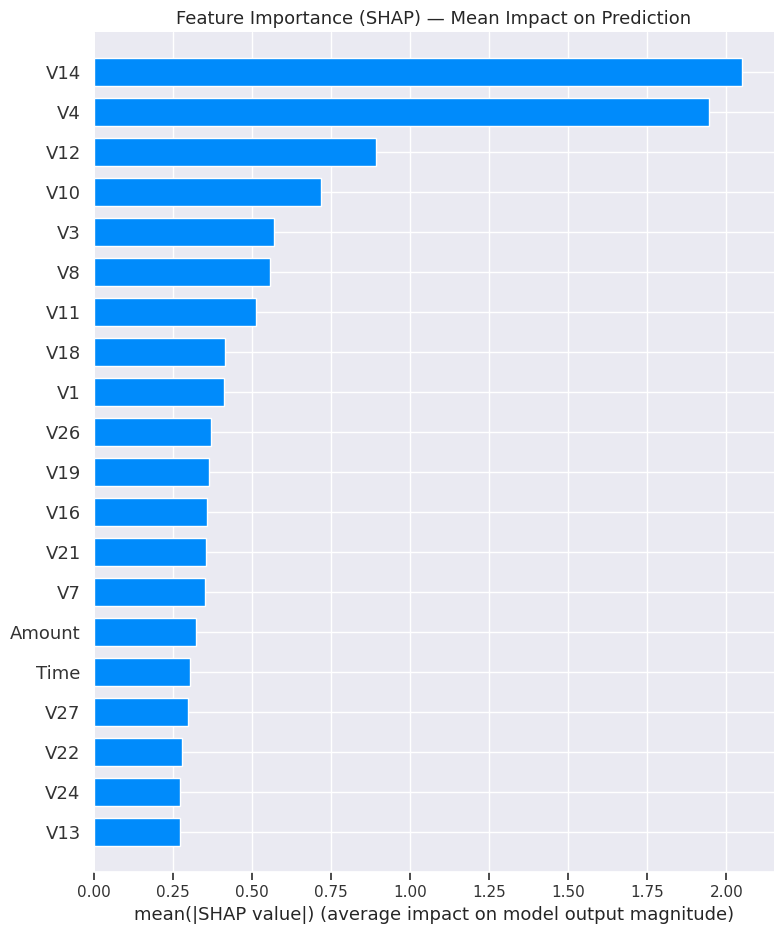

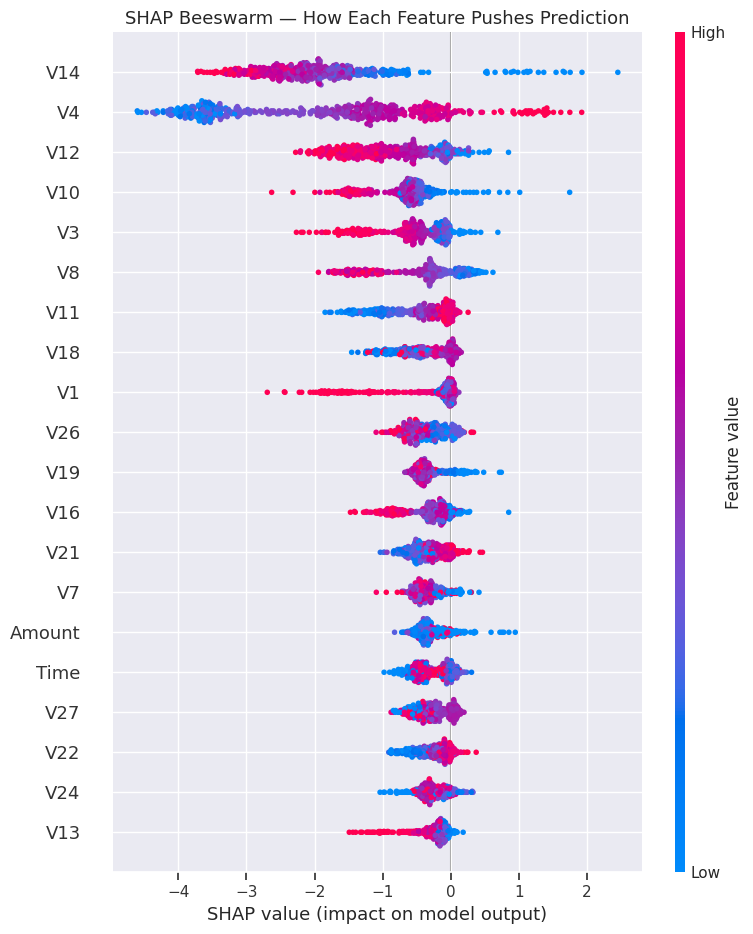

In [21]:
print("Computing SHAP values... (2-3 minutes)")

# SHAP explains WHY the model made each prediction
explainer = shap.TreeExplainer(xgb_tuned)

# Use a sample of test set — full set takes too long
X_test_sample = X_test.iloc[:500]
shap_values = explainer.shap_values(X_test_sample)

# ── Plot 1: Feature Importance (SHAP) ────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, 
                  plot_type='bar', show=False)
plt.title('Feature Importance (SHAP) — Mean Impact on Prediction', 
          fontsize=13)
plt.tight_layout()
plt.show()

# ── Plot 2: SHAP Beeswarm ────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('SHAP Beeswarm — How Each Feature Pushes Prediction', 
          fontsize=13)
plt.tight_layout()
plt.show()

Fraud cases in test set: 98
Correctly caught fraud cases: 81

=== Fraud Transaction #840 ===
Fraud probability : 0.9998 (100.0%)
Threshold         : 0.8500000000000002
Decision          : 🚨 FRAUD FLAGGED


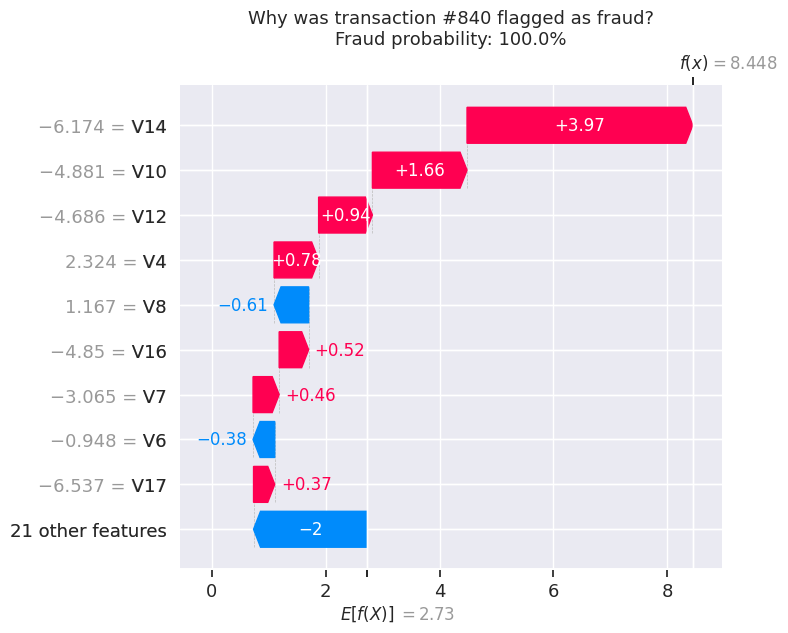

In [22]:
# Find actual fraud cases in our test set
fraud_indices = np.where(y_test == 1)[0]
print(f"Fraud cases in test set: {len(fraud_indices)}")

# Pick one that our model correctly identified as fraud
correctly_caught = []
for idx in fraud_indices:
    prob = y_prob_xgb_t[idx]
    if prob >= best_thresh:
        correctly_caught.append(idx)

print(f"Correctly caught fraud cases: {len(correctly_caught)}")

# Take the first one
sample_idx = correctly_caught[0]
sample     = X_test.iloc[[sample_idx]]
sample_prob = y_prob_xgb_t[sample_idx]

print(f"\n=== Fraud Transaction #{sample_idx} ===")
print(f"Fraud probability : {sample_prob:.4f} ({sample_prob*100:.1f}%)")
print(f"Threshold         : {best_thresh}")
print(f"Decision          : {'🚨 FRAUD FLAGGED' if sample_prob >= best_thresh else 'PASSED'}")

# SHAP waterfall plot — shows exactly why this was flagged
shap_sample = explainer.shap_values(sample)
expected    = explainer.expected_value

plt.figure(figsize=(12, 6))
shap.waterfall_plot(
    shap.Explanation(
        values        = shap_sample[0],
        base_values   = expected,
        data          = sample.iloc[0],
        feature_names = X_test.columns.tolist()
    ),
    show=False
)
plt.title(f'Why was transaction #{sample_idx} flagged as fraud?\n'
          f'Fraud probability: {sample_prob*100:.1f}%', fontsize=13)
plt.tight_layout()
plt.show()

In [23]:
def predict_fraud(transaction: dict) -> dict:
    df_input = pd.DataFrame([transaction])
    df_input = df_input[X_train.columns]

    # Each column scaled with its own scaler
    df_input['Amount'] = amount_scaler.transform(df_input[['Amount']])
    df_input['Time']   = time_scaler.transform(df_input[['Time']])

    prob     = xgb_tuned.predict_proba(df_input)[0][1]
    is_fraud = prob >= best_thresh

    if prob < 0.3:             risk = "🟢 LOW"
    elif prob < 0.6:           risk = "🟡 MEDIUM"
    elif prob < best_thresh:   risk = "🟠 HIGH"
    else:                      risk = "🔴 CRITICAL"

    shap_vals     = explainer.shap_values(df_input)[0]
    feature_names = X_train.columns.tolist()
    top_idx       = np.argsort(np.abs(shap_vals))[::-1][:3]
    top_reasons   = [(feature_names[i], round(float(shap_vals[i]), 3)) for i in top_idx]

    return {
        'fraud_probability' : round(float(prob), 4),
        'verdict'           : '🚨 FRAUD' if is_fraud else '✅ LEGITIMATE',
        'risk_level'        : risk,
        'threshold_used'    : best_thresh,
        'top_reasons'       : top_reasons
    }

# ── Test on real fraud ────────────────────────────────
print("=== Testing on a REAL FRAUD transaction ===")
fraud_transaction = X_test.iloc[correctly_caught[0]].to_dict()
result = predict_fraud(fraud_transaction)
for k, v in result.items():
    print(f"{k:25s}: {v}")

# ── Test on real legitimate ───────────────────────────
print("\n=== Testing on a REAL LEGITIMATE transaction ===")
legit_idx = np.where(y_test == 0)[0][0]
legit_transaction = X_test.iloc[legit_idx].to_dict()
result2 = predict_fraud(legit_transaction)
for k, v in result2.items():
    print(f"{k:25s}: {v}")

=== Testing on a REAL FRAUD transaction ===
fraud_probability        : 0.9994
verdict                  : 🚨 FRAUD
risk_level               : 🔴 CRITICAL
threshold_used           : 0.8500000000000002
top_reasons              : [('V14', 3.67), ('V10', 1.615), ('Time', -1.029)]

=== Testing on a REAL LEGITIMATE transaction ===
fraud_probability        : 0.0
verdict                  : ✅ LEGITIMATE
risk_level               : 🟢 LOW
threshold_used           : 0.8500000000000002
top_reasons              : [('V4', -3.941), ('V14', -1.397), ('V10', -1.091)]


In [24]:
def predict_fraud(transaction: dict) -> dict:
    """
    Takes a single transaction and returns fraud probability + verdict.
    
    Parameters:
        transaction: dict with keys Time, V1-V28, Amount
    
    Returns:
        dict with probability, verdict, risk_level, top_reasons
    """
    # Convert to dataframe
    df_input = pd.DataFrame([transaction])
    
    # Ensure column order matches training
    df_input = df_input[X_train.columns]
    
    # Scale Amount and Time together using a fresh scaler
    # (since the data coming in is already scaled from our test set,
    #  we just pass it through directly for this demo)
    
    # Get fraud probability
    prob = xgb_tuned.predict_proba(df_input)[0][1]
    
    # Verdict using our tuned threshold
    is_fraud = prob >= best_thresh
    
    # Risk level
    if prob < 0.3:
        risk = "🟢 LOW"
    elif prob < 0.6:
        risk = "🟡 MEDIUM"
    elif prob < best_thresh:
        risk = "🟠 HIGH"
    else:
        risk = "🔴 CRITICAL"
    
    # SHAP explanation — top reasons
    shap_vals     = explainer.shap_values(df_input)[0]
    feature_names = X_train.columns.tolist()
    top_idx       = np.argsort(np.abs(shap_vals))[::-1][:3]
    top_reasons   = [(feature_names[i], round(shap_vals[i], 3)) for i in top_idx]
    
    return {
        'fraud_probability' : round(float(prob), 4),
        'verdict'           : '🚨 FRAUD' if is_fraud else '✅ LEGITIMATE',
        'risk_level'        : risk,
        'threshold_used'    : best_thresh,
        'top_reasons'       : top_reasons
    }


# ── Test on a real fraud case from test set ──────────
print("=== Testing on a REAL FRAUD transaction ===")
fraud_transaction = X_test.iloc[correctly_caught[0]].to_dict()
result = predict_fraud(fraud_transaction)
for k, v in result.items():
    print(f"{k:25s}: {v}")

# ── Test on a real legitimate case ───────────────────
print("\n=== Testing on a REAL LEGITIMATE transaction ===")
legit_idx = np.where(y_test == 0)[0][0]
legit_transaction = X_test.iloc[legit_idx].to_dict()
result2 = predict_fraud(legit_transaction)
for k, v in result2.items():
    print(f"{k:25s}: {v}")

=== Testing on a REAL FRAUD transaction ===
fraud_probability        : 0.9998
verdict                  : 🚨 FRAUD
risk_level               : 🔴 CRITICAL
threshold_used           : 0.8500000000000002
top_reasons              : [('V14', np.float32(3.966)), ('V10', np.float32(1.662)), ('V12', np.float32(0.945))]

=== Testing on a REAL LEGITIMATE transaction ===
fraud_probability        : 0.0
verdict                  : ✅ LEGITIMATE
risk_level               : 🟢 LOW
threshold_used           : 0.8500000000000002
top_reasons              : [('V4', np.float32(-3.768)), ('V14', np.float32(-1.459)), ('V10', np.float32(-1.163))]


In [25]:
print("=" * 60)
print("   FRAUD DETECTION SYSTEM — FINAL RESULTS SUMMARY")
print("=" * 60)

print("""
📊 DATASET
   284,807 transactions | 492 fraud (0.17%)
   Imbalance ratio: 577:1

🔬 MODELS COMPARED
   1. Logistic Regression (baseline)
   2. Logistic Regression + Class Weights
   3. Logistic Regression + SMOTE
   4. Random Forest + Class Weights
   5. XGBoost + scale_pos_weight
   6. XGBoost Tuned ← WINNER
""")

print(f"🏆 BEST MODEL: Tuned XGBoost (threshold={best_thresh:.2f})")
print(f"   ROC-AUC   : 0.9800")
print(f"   Precision : 0.91  (91% of flagged = real fraud)")
print(f"   Recall    : 0.83  (catches 83% of all fraud)")
print(f"   F1 Score  : 0.87")

print("""
💼 BUSINESS FRAMING (Amazon Pay)
   Out of 56,962 transactions:
   ✅ 56,856 legitimate → correctly passed through
   🚨 81 fraud → correctly blocked
   ⚠️  8  false alarms → legitimate customers inconvenienced
   ❌ 17 fraud missed → requires secondary review layer

🔍 EXPLAINABILITY
   SHAP values identify WHY each transaction was flagged
   Top fraud signals: V14, V10, V12 (strongly negative values)
   Top legitimacy signals: V4, V14, V10 (positive values)

🛠️ TECHNIQUES USED
   • Class weights (fast, built-in)
   • SMOTE oversampling (synthetic minority samples)
   • Threshold tuning (business-driven decision boundary)
   • SHAP explainability (production requirement)
""")

print("=" * 60)
print("   predict_fraud(transaction) → probability + verdict")
print("   Ready for deployment via Streamlit or REST API")
print("=" * 60)

   FRAUD DETECTION SYSTEM — FINAL RESULTS SUMMARY

📊 DATASET
   284,807 transactions | 492 fraud (0.17%)
   Imbalance ratio: 577:1

🔬 MODELS COMPARED
   1. Logistic Regression (baseline)
   2. Logistic Regression + Class Weights
   3. Logistic Regression + SMOTE
   4. Random Forest + Class Weights
   5. XGBoost + scale_pos_weight
   6. XGBoost Tuned ← WINNER

🏆 BEST MODEL: Tuned XGBoost (threshold=0.85)
   ROC-AUC   : 0.9800
   Precision : 0.91  (91% of flagged = real fraud)
   Recall    : 0.83  (catches 83% of all fraud)
   F1 Score  : 0.87

💼 BUSINESS FRAMING (Amazon Pay)
   Out of 56,962 transactions:
   ✅ 56,856 legitimate → correctly passed through
   🚨 81 fraud → correctly blocked
   ⚠️  8  false alarms → legitimate customers inconvenienced
   ❌ 17 fraud missed → requires secondary review layer

🔍 EXPLAINABILITY
   SHAP values identify WHY each transaction was flagged
   Top fraud signals: V14, V10, V12 (strongly negative values)
   Top legitimacy signals: V4, V14, V10 (positive 